# Long-duration Category 3–5 IBTrACS statistics

This notebook scans the IBTrACS CSV under `data/ibtracs` for one basin, inclusive season range, and reporting center. It finds the first closed Category 3–5 threshold interval for each storm, prints the same nine-column statistics table as the B-deck notebook, and plots annual mean duration with annual TC counts.

Center mapping follows the available IBTrACS columns:

- `JTWC`: `USA_WIND` and `USA_PRES`, restricted to rows whose `USA_AGENCY` begins with `jtwc_`.
- `USA`: all available `USA_WIND` and `USA_PRES` values.
- `JMA`: `TOKYO_WIND` and `TOKYO_PRES`.

The default `VMAX > 95 kt` condition represents Category 3–5 intensity because Category 3 begins at 96 kt and the comparison is strict. Threshold intervals are `[start_cycle, end_cycle)`, so the first non-qualifying ending record is excluded from the extrema. Open-ended intervals are reported in the summary but excluded because their complete duration is unknown.

In [1]:
from __future__ import annotations

import csv
from datetime import datetime
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

try:
    from src import mod_verification as verif
except ModuleNotFoundError as exc:
    if exc.name != "src":
        raise
    import mod_verification as verif

## Inputs

IBTrACS basin codes include `NA`, `EP`, `WP`, `NI`, `SI`, `SP`, and `SA`. `start_year` and `end_year` are inclusive. The duration comparison is strict: 72 retains intervals longer than 72 hours.

In [2]:
basin = "WP"
start_year = 1980
end_year = 2024
center = "JTWC"  # One of JTWC, USA, or JMA.

threshold_metric = "VMAX"
threshold_value = 95
minimum_duration_hours = 72

In [3]:
IBTRACS_PATH = (
    verif.PROJECT_ROOT
    / "data"
    / "ibtracs"
    / "ibtracs.ALL.list.v04r00.csv"
)
BASIN_NAMES = {
    "NA": "North Atlantic",
    "EP": "Eastern Pacific",
    "WP": "Western Pacific",
    "NI": "North Indian",
    "SI": "South Indian",
    "SP": "South Pacific",
    "SA": "South Atlantic",
}
CENTER_FIELDS = {
    "JTWC": ("USA_WIND", "USA_PRES"),
    "USA": ("USA_WIND", "USA_PRES"),
    "JMA": ("TOKYO_WIND", "TOKYO_PRES"),
}

basin = str(basin).strip().upper()
center = str(center).strip().upper()
if basin not in BASIN_NAMES:
    raise ValueError(f"basin must be one of {sorted(BASIN_NAMES)}.")
if center not in CENTER_FIELDS:
    raise ValueError(f"center must be one of {sorted(CENTER_FIELDS)}.")
if isinstance(start_year, bool) or not isinstance(start_year, int):
    raise ValueError("start_year must be an integer.")
if isinstance(end_year, bool) or not isinstance(end_year, int):
    raise ValueError("end_year must be an integer.")
if start_year > end_year:
    raise ValueError("start_year must not be later than end_year.")
if not IBTRACS_PATH.is_file():
    raise FileNotFoundError(f"IBTrACS file not found: {IBTRACS_PATH}")

In [4]:
def parse_positive_float(value: str) -> Optional[float]:
    try:
        parsed = float(value.strip())
    except (AttributeError, TypeError, ValueError):
        return None
    return parsed if parsed > 0 else None


def center_values(row: Dict[str, str], selected_center: str) -> Tuple[Optional[float], Optional[float]]:
    """Return center-specific VMAX and PMIN in kt and hPa."""
    if selected_center == "JTWC":
        agency = row["USA_AGENCY"].strip().lower()
        if not agency.startswith("jtwc_"):
            return None, None
    wind_field, pressure_field = CENTER_FIELDS[selected_center]
    return (
        parse_positive_float(row[wind_field]),
        parse_positive_float(row[pressure_field]),
    )


def find_ibtracs_threshold_period(
    records: Dict[datetime, Dict[str, Optional[float]]],
    metric: str,
    threshold: float,
) -> Tuple[Optional[datetime], Optional[datetime]]:
    """Return the first qualifying half-open interval [start, end)."""
    metric = str(metric).strip().upper()
    if metric not in {"VMAX", "PMIN"}:
        raise ValueError("IBTrACS threshold metric must be VMAX or PMIN.")
    if isinstance(threshold, bool):
        raise ValueError("threshold must be numeric.")
    threshold = float(threshold)

    def qualifies(cycle: datetime) -> bool:
        value = records[cycle].get(metric)
        if value is None:
            return False
        return value < threshold if metric == "PMIN" else value > threshold

    start_time: Optional[datetime] = None
    for cycle in sorted(records):
        if start_time is None:
            if qualifies(cycle):
                start_time = cycle
        elif not qualifies(cycle):
            return start_time, cycle
    return (start_time, None) if start_time is not None else (None, None)


def values_in_period(
    records: Dict[datetime, Dict[str, Optional[float]]],
    metric: str,
    start_time: datetime,
    end_time: datetime,
) -> List[float]:
    return [
        values[metric]
        for cycle, values in records.items()
        if start_time <= cycle < end_time and values.get(metric) is not None
    ]


def display_value(value: Optional[float]) -> Any:
    if value is None:
        return "NA"
    return int(value) if float(value).is_integer() else round(float(value), 2)


def print_table(rows: Sequence[Dict[str, Any]], columns: Sequence[str]) -> None:
    text_rows = [[str(row[column]) for column in columns] for row in rows]
    widths = [
        max([len(column)] + [len(row[index]) for row in text_rows])
        for index, column in enumerate(columns)
    ]
    header = " | ".join(column.ljust(width) for column, width in zip(columns, widths))
    separator = "-+-".join("-" * width for width in widths)
    print(header)
    print(separator)
    for row in text_rows:
        print(" | ".join(value.ljust(width) for value, width in zip(row, widths)))

## Read the selected IBTrACS subset

In [5]:
storms: Dict[str, Dict[str, Any]] = {}
rows_examined = 0
rows_selected = 0
center_rows_selected = 0

with IBTRACS_PATH.open("r", encoding="utf-8", errors="replace", newline="") as handle:
    reader = csv.DictReader(handle)
    for row in reader:
        rows_examined += 1
        sid = row["SID"].strip()
        if not sid:  # Skip the units row directly below the CSV header.
            continue
        if row["BASIN"].strip().upper() != basin:
            continue
        try:
            season = int(row["SEASON"].strip())
            cycle = datetime.strptime(row["ISO_TIME"].strip(), "%Y-%m-%d %H:%M:%S")
        except (TypeError, ValueError):
            continue
        if not start_year <= season <= end_year:
            continue

        rows_selected += 1
        vmax, pmin = center_values(row, center)
        if vmax is None and pmin is None:
            continue
        center_rows_selected += 1
        storm = storms.setdefault(
            sid,
            {
                "name": "UNKNOWN",
                "sid": sid,
                "basin": basin,
                "year": season,
                "records": {},
            },
        )
        candidate_name = row["NAME"].strip().upper()
        if candidate_name and candidate_name not in {"NOT_NAMED", "UNNAMED"}:
            storm["name"] = candidate_name
        elif storm["name"] == "UNKNOWN" and candidate_name:
            storm["name"] = candidate_name
        storm["records"][cycle] = {"VMAX": vmax, "PMIN": pmin}

print(f"IBTrACS rows examined: {rows_examined}")
print(f"Rows selected for {basin}, {start_year}–{end_year}: {rows_selected}")
print(f"Rows with {center} intensity data: {center_rows_selected}")
print(f"Storms selected: {len(storms)}")

IBTrACS rows examined: 711401
Rows selected for WP, 1980–2024: 97372
Rows with JTWC intensity data: 38634
Storms selected: 1286


## Calculate and print qualifying statistics

In [6]:
results: List[Dict[str, Any]] = []
open_intervals_skipped = 0

for storm in storms.values():
    records = storm["records"]
    start_time, end_time = find_ibtracs_threshold_period(
        records, threshold_metric, threshold_value
    )
    if start_time is None:
        continue
    if end_time is None:
        open_intervals_skipped += 1
        continue

    duration_hours = int((end_time - start_time).total_seconds() / 3600)
    if duration_hours <= minimum_duration_hours:
        continue

    vmax_values = values_in_period(records, "VMAX", start_time, end_time)
    pmin_values = values_in_period(records, "PMIN", start_time, end_time)
    results.append(
        {
            "storm name": storm["name"],
            "storm id": storm["sid"],
            "basin": BASIN_NAMES[storm["basin"]],
            "year": storm["year"],
            "start_cycle": start_time.strftime("%Y%m%d%H"),
            "end_cycle": end_time.strftime("%Y%m%d%H"),
            "duration (h)": duration_hours,
            "max VMAX (kt)": display_value(max(vmax_values) if vmax_values else None),
            "min PMIN (hPa)": display_value(min(pmin_values) if pmin_values else None),
        }
    )

results.sort(key=lambda row: (row["year"], row["storm id"]))
columns = [
    "storm name",
    "storm id",
    "basin",
    "year",
    "start_cycle",
    "end_cycle",
    "duration (h)",
    "max VMAX (kt)",
    "min PMIN (hPa)",
]
print_table(results, columns)
print()
print(f"Center: {center}; basin: {basin}; seasons: {start_year}–{end_year}")
print(f"Qualifying closed intervals longer than {minimum_duration_hours} h: {len(results)}")
print(f"Open-ended threshold intervals skipped: {open_intervals_skipped}")

storm name | storm id      | basin           | year | start_cycle | end_cycle  | duration (h) | max VMAX (kt) | min PMIN (hPa)
-----------+---------------+-----------------+------+-------------+------------+--------------+---------------+---------------
ELLEN      | 1980133N07149 | Western Pacific | 1980 | 1980051518  | 1980051912 | 90           | 110           | NA            
WYNNE      | 1980277N09157 | Western Pacific | 1980 | 1980100900  | 1980101300 | 96           | 150           | NA            
ELSIE      | 1981266N09151 | Western Pacific | 1981 | 1981092612  | 1981100106 | 114          | 150           | NA            
BESS       | 1982202N11165 | Western Pacific | 1982 | 1982072806  | 1982073112 | 78           | 140           | NA            
ELLIS      | 1982229N09154 | Western Pacific | 1982 | 1982082200  | 1982082506 | 78           | 125           | NA            
MAC        | 1982272N11156 | Western Pacific | 1982 | 1982100400  | 1982100818 | 114          | 140           |

## Annual mean duration and TC count

In [7]:
def plot_annual_duration_and_counts(
    rows: Sequence[Dict[str, Any]],
    *,
    title: Optional[str] = None,
    figsize: Tuple[float, float] = (14, 6),
):
    """Plot annual mean duration and qualifying-TC count on twin axes."""
    if not rows:
        raise ValueError("At least one qualifying storm is required.")

    durations_by_year: Dict[int, List[float]] = {}
    for row in rows:
        year = int(row["year"])
        duration = float(row["duration (h)"])
        durations_by_year.setdefault(year, []).append(duration)

    years = list(range(start_year, end_year + 1))
    mean_durations = [
        sum(durations_by_year[year]) / len(durations_by_year[year])
        if year in durations_by_year
        else float("nan")
        for year in years
    ]
    tc_counts = [len(durations_by_year.get(year, [])) for year in years]

    fig, duration_axis = plt.subplots(figsize=figsize)
    count_axis = duration_axis.twinx()
    count_axis.bar(
        years, tc_counts, width=0.8, color="tab:orange", alpha=0.3, label="TC count"
    )
    duration_axis.plot(
        years,
        mean_durations,
        color="tab:blue",
        marker="o",
        linewidth=2,
        label="Mean duration",
    )
    duration_axis.set_xlabel("Year")
    duration_axis.set_ylabel("Average qualifying duration (h)", color="tab:blue")
    count_axis.set_ylabel("Number of TCs", color="tab:orange")
    duration_axis.tick_params(axis="y", labelcolor="tab:blue")
    count_axis.tick_params(axis="y", labelcolor="tab:orange")
    count_axis.yaxis.set_major_locator(MaxNLocator(integer=True))
    duration_axis.set_xticks(years)
    duration_axis.set_xticklabels(years, rotation=90, fontsize=8)
    duration_axis.set_xlim(years[0] - 0.75, years[-1] + 0.75)
    duration_axis.grid(axis="y", alpha=0.3)
    if title is None:
        title = f"Annual Category 3–5 duration and TC count: {basin}, {center}"
    duration_axis.set_title(title)

    handles_left, labels_left = duration_axis.get_legend_handles_labels()
    handles_right, labels_right = count_axis.get_legend_handles_labels()
    duration_axis.legend(
        handles_left + handles_right, labels_left + labels_right, loc="upper left"
    )
    fig.tight_layout()
    return fig, (duration_axis, count_axis)

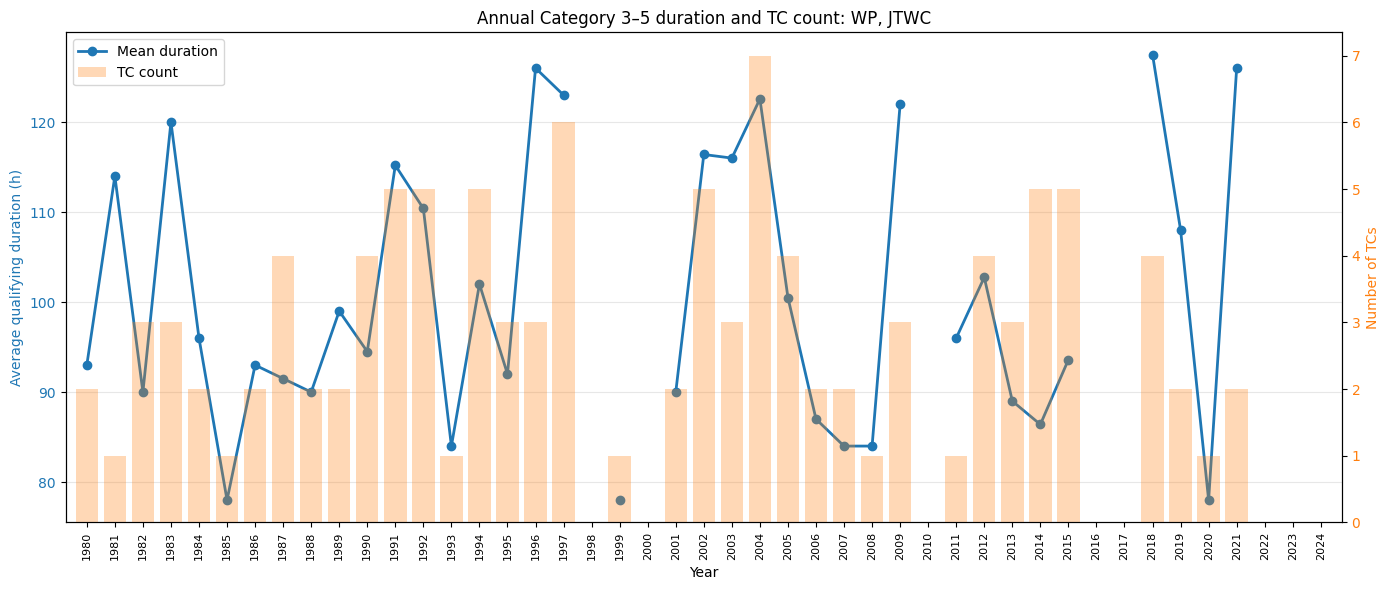

In [8]:
if results:
    annual_fig, annual_axes = plot_annual_duration_and_counts(results)
else:
    print("No qualifying storms are available to plot for these inputs.")